In [ ]:
from google.colab import drive
drive.mount('/content/drive')

In [2]:
new_base_dir = '/content/drive/MyDrive/BSM VII/Deep Learning/Intel Image Classification Small'

In [3]:
import os

print(new_base_dir)
print(os.listdir(new_base_dir))

/content/drive/MyDrive/BSM VII/Deep Learning/Intel Image Classification Small
['test', 'train']


In [4]:
from tensorflow.keras.utils import image_dataset_from_directory

all_train = image_dataset_from_directory(
    new_base_dir + "/train",
    image_size=(180, 180),
    batch_size=None,
    label_mode="categorical",
    shuffle=False
)
all_test = image_dataset_from_directory(
    new_base_dir + "/test",
    image_size=(180, 180),
    batch_size=None,
    label_mode="categorical",
    shuffle=False
)

test_count = len(all_test.file_paths)
train_count = len(all_train.file_paths)

Found 864 files belonging to 6 classes.
Found 600 files belonging to 6 classes.


In [5]:
all_train = all_train.shuffle(train_count,
                              seed=42,
                              reshuffle_each_iteration=False)
all_test = all_test.shuffle(test_count,
                            seed=42,
                            reshuffle_each_iteration=False)

train_dataset = all_train.take(100).batch(16)
validation_dataset = all_train.skip(100).take(44).batch(16)
test_dataset = all_test.take(100).batch(16)

In [6]:
for images, labels in train_dataset.take(1):
    print("Image batch shape:", images.shape)
    print("Label batch shape:", labels.shape)
    print("First image label:", labels[0].numpy())

Image batch shape: (16, 180, 180, 3)
Label batch shape: (16, 6)
First image label: [0. 0. 0. 0. 1. 0.]


In [7]:
from tensorflow import keras
from tensorflow.keras import layers

inputs = keras.Input(shape=(180, 180, 3))
x = layers.Rescaling(1./255)(inputs)
x = layers.Conv2D(filters=32, kernel_size=3, activation="relu", padding="same")(x)
x = layers.MaxPooling2D(pool_size=2)(x)
x = layers.Conv2D(filters=64, kernel_size=3, activation="relu", padding="same")(x)
x = layers.MaxPooling2D(pool_size=2)(x)
x = layers.Conv2D(filters=128, kernel_size=3, activation="relu", padding="same")(x)
x = layers.MaxPooling2D(pool_size=2)(x)
x = layers.Conv2D(filters=256, kernel_size=3, activation="relu", padding="same")(x)
x = layers.MaxPooling2D(pool_size=2)(x)
x = layers.Conv2D(filters=512, kernel_size=3, activation="relu", padding="same")(x)
x = layers.MaxPooling2D(pool_size=2)(x)
x = layers.Conv2D(filters=1024, kernel_size=3, activation="relu", padding="same")(x)
x = layers.MaxPooling2D(pool_size=2)(x)
x = layers.Flatten()(x)

# Six output probabilities: one for each scene class
outputs = layers.Dense(6, activation="softmax")(x)
model = keras.Model(inputs=inputs, outputs=outputs)
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 180, 180, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling (Rescaling)           │ (None, 180, 180, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 180, 180, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 90, 90, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 90, 90, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 45, 45, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 45, 45, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 22, 22, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 22, 22, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 11, 11, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 11, 11, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 5, 5, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 5, 5, 1024)     │     4,719,616 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 2, 2, 1024)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 6)              │        24,582 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,312,774 (24.08 MB)

 Trainable params: 6,312,774 (24.08 MB)

 Non-trainable params: 0 (0.00 B)

In [8]:
model.compile(
    loss="categorical_crossentropy",
    optimizer="rmsprop",
    metrics=["accuracy"]
)

In [9]:
callbacks = [
    keras.callbacks.ModelCheckpoint(
        filepath="convent_without_aug.keras",
        save_best_only=True,
        monitor="val_loss")]

history = model.fit(
    train_dataset,
    epochs=20,
    validation_data=validation_dataset,
    callbacks=callbacks
)

Epoch 1/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 23s 3s/step - accuracy: 0.1600 - loss: 1.8855 - val_accuracy: 0.1364 - val_loss: 1.7917
Epoch 2/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 20s 3s/step - accuracy: 0.2000 - loss: 1.7915 - val_accuracy: 0.1591 - val_loss: 1.7899
Epoch 3/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 28s 4s/step - accuracy: 0.2200 - loss: 1.7875 - val_accuracy: 0.1591 - val_loss: 1.7894
Epoch 4/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 21s 3s/step - accuracy: 0.2300 - loss: 1.7809 - val_accuracy: 0.1591 - val_loss: 1.7761
Epoch 5/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 25s 3s/step - accuracy: 0.1700 - loss: 1.7984 - val_accuracy: 0.1591 - val_loss: 1.8031
Epoch 6/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 35s 3s/step - accuracy: 0.2200 - loss: 1.7820 - val_accuracy: 0.1591 - val_loss: 1.7900
Epoch 7/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 22s 3s/step - accuracy: 0.2200 - loss: 1.7725 - val_accuracy: 0.1364 - val_loss: 1.8015
Epoch 8/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 20s 3s/step - accuracy: 0.2300 - loss: 2.1550 - val_accuracy: 0.1364 - val_loss: 1.8493
Epoch 9/

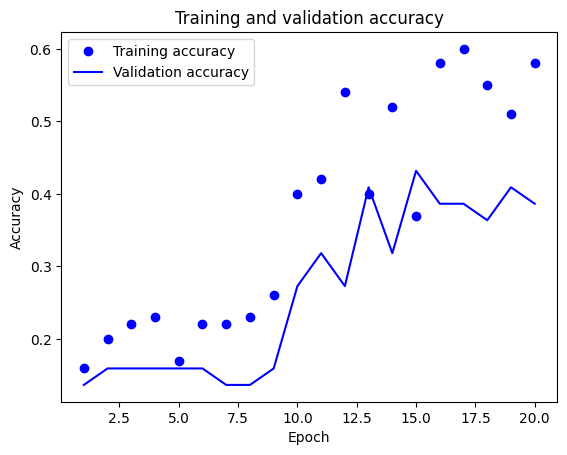

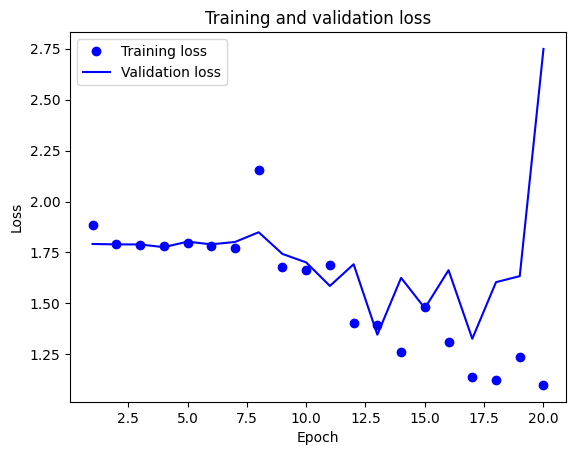

In [10]:
import matplotlib.pyplot as plt

accuracy = history.history["accuracy"]
val_accuracy = history.history["val_accuracy"]

loss = history.history["loss"]
val_loss = history.history["val_loss"]

epochs = range(1, len(accuracy) + 1)

# Accuracy plot
plt.figure()
plt.plot(epochs, accuracy, "bo", label="Training accuracy")
plt.plot(epochs, val_accuracy, "b", label="Validation accuracy")
plt.title("Training and validation accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

# Loss plot
plt.figure()
plt.plot(epochs, loss, "bo", label="Training loss")
plt.plot(epochs, val_loss, "b", label="Validation loss")
plt.title("Training and validation loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.show()

In [11]:
test_loss, test_acc = model.evaluate(test_dataset)

print(f"Test loss: {test_loss:.4f}")
print(f"Test accuracy: {test_acc:.2%}")

7/7 ━━━━━━━━━━━━━━━━━━━━ 94s 423ms/step - accuracy: 0.2800 - loss: 3.1889
Test loss: 3.1889
Test accuracy: 28.00%


In [12]:
baseline_test_loss = test_loss
baseline_test_acc = test_acc

#CNN with augmentation and dropout

In [13]:
data_augmentation = keras.Sequential([
    layers.RandomFlip("vertical"),
    layers.RandomRotation(0.3),
    layers.RandomZoom(0.3)
])

In [14]:
inputs = keras.Input(shape=(180, 180, 3))

x = data_augmentation(inputs)
x = layers.Rescaling(1./255)(x)

x = layers.Conv2D(32, kernel_size=3, activation="relu", padding="same")(x)
x = layers.MaxPooling2D(pool_size=2)(x)
x = layers.Conv2D(64, kernel_size=3, activation="relu", padding="same")(x)
x = layers.MaxPooling2D(pool_size=2)(x)
x = layers.Conv2D(128, kernel_size=3, activation="relu", padding="same")(x)
x = layers.MaxPooling2D(pool_size=2)(x)
x = layers.Conv2D(256, kernel_size=3, activation="relu", padding="same")(x)
x = layers.MaxPooling2D(pool_size=2)(x)
x = layers.Conv2D(512, kernel_size=3, activation="relu", padding="same")(x)
x = layers.MaxPooling2D(pool_size=2)(x)
x = layers.Conv2D(1024, kernel_size=3, activation="relu", padding="same")(x)
x = layers.MaxPooling2D(pool_size=2)(x)
x = layers.Flatten()(x)
x = layers.Dropout(0.5)(x)

outputs = layers.Dense(6, activation="softmax")(x)
augmented_model = keras.Model(inputs=inputs, outputs=outputs)
augmented_model.summary()

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 180, 180, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential (Sequential)         │ (None, 180, 180, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling_1 (Rescaling)         │ (None, 180, 180, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 180, 180, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 90, 90, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 90, 90, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 45, 45, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 45, 45, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 22, 22, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 22, 22, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 11, 11, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 11, 11, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_10 (MaxPooling2D) │ (None, 5, 5, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 5, 5, 1024)     │     4,719,616 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_11 (MaxPooling2D) │ (None, 2, 2, 1024)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 6)              │        24,582 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,312,774 (24.08 MB)

 Trainable params: 6,312,774 (24.08 MB)

 Non-trainable params: 0 (0.00 B)

In [15]:
augmented_model.compile(
    loss="categorical_crossentropy",
    optimizer="rmsprop",
    metrics=["accuracy"]
)

callbacks = [
    keras.callbacks.ModelCheckpoint(
        filepath="convent_with_aug.keras",
        save_best_only=True,
        monitor="val_loss")]
augmented_history = augmented_model.fit(
    train_dataset,
    epochs=20,
    validation_data=validation_dataset,
    callbacks=callbacks
)

Epoch 1/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 24s 3s/step - accuracy: 0.2000 - loss: 1.8464 - val_accuracy: 0.1591 - val_loss: 1.7931
Epoch 2/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 20s 3s/step - accuracy: 0.2200 - loss: 1.7902 - val_accuracy: 0.1591 - val_loss: 1.7898
Epoch 3/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 20s 3s/step - accuracy: 0.2200 - loss: 1.7868 - val_accuracy: 0.1591 - val_loss: 1.7720
Epoch 4/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 23s 3s/step - accuracy: 0.2900 - loss: 1.8929 - val_accuracy: 0.1364 - val_loss: 2.6459
Epoch 5/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 24s 3s/step - accuracy: 0.1900 - loss: 1.8815 - val_accuracy: 0.2045 - val_loss: 1.7468
Epoch 6/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 23s 3s/step - accuracy: 0.1800 - loss: 1.7376 - val_accuracy: 0.3636 - val_loss: 1.6819
Epoch 7/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 20s 3s/step - accuracy: 0.3100 - loss: 1.7217 - val_accuracy: 0.2727 - val_loss: 1.6764
Epoch 8/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 20s 3s/step - accuracy: 0.3100 - loss: 1.6916 - val_accuracy: 0.1818 - val_loss: 1.6770
Epoch 9/

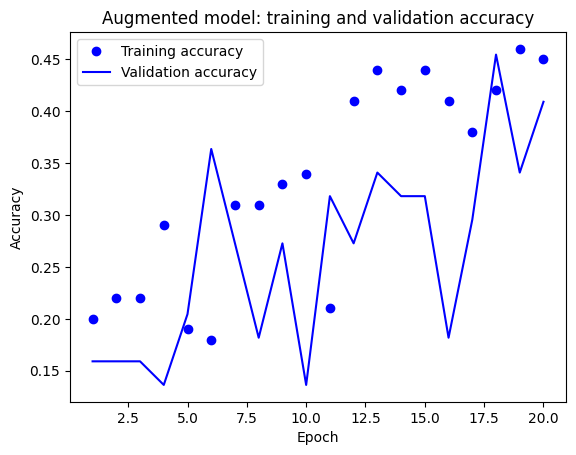

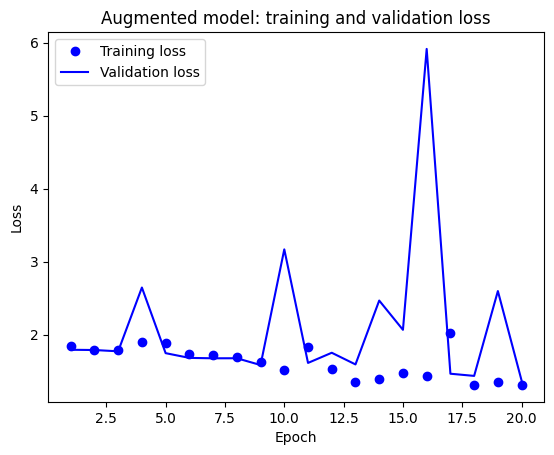

In [16]:
import matplotlib.pyplot as plt

accuracy = augmented_history.history["accuracy"]
val_accuracy = augmented_history.history["val_accuracy"]
loss = augmented_history.history["loss"]
val_loss = augmented_history.history["val_loss"]

epochs = range(1, len(accuracy) + 1)

plt.figure()
plt.plot(epochs, accuracy, "bo", label="Training accuracy")
plt.plot(epochs, val_accuracy, "b", label="Validation accuracy")
plt.title("Augmented model: training and validation accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.figure()
plt.plot(epochs, loss, "bo", label="Training loss")
plt.plot(epochs, val_loss, "b", label="Validation loss")
plt.title("Augmented model: training and validation loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.show()

In [17]:
test_loss, test_acc = augmented_model.evaluate(test_dataset)

print(f"Test loss: {test_loss:.4f}")
print(f"Test accuracy: {test_acc:.2%}")

7/7 ━━━━━━━━━━━━━━━━━━━━ 5s 411ms/step - accuracy: 0.3400 - loss: 1.4947
Test loss: 1.4947
Test accuracy: 34.00%


In [18]:
augmented_test_loss, augmented_test_acc = augmented_model.evaluate(
    test_dataset
)

print(f"Augmented model test loss: {augmented_test_loss:.4f}")
print(f"Augmented model test accuracy: {augmented_test_acc:.2%}")

7/7 ━━━━━━━━━━━━━━━━━━━━ 4s 411ms/step - accuracy: 0.3400 - loss: 1.4947
Augmented model test loss: 1.4947
Augmented model test accuracy: 34.00%


In [19]:
print(f"Without augmentation: {baseline_test_acc:.2%}")
print(f"With augmentation and dropout: {augmented_test_acc:.2%}")

Without augmentation: 28.00%
With augmentation and dropout: 34.00%


In [20]:
import numpy as np
from tensorflow.keras.utils import load_img, img_to_array

# Must match the class order used when loading your datasets
class_names = [
    "buildings", "forest", "glacier",
    "mountain", "sea", "street"
]

def predict_scene(image_path, trained_model):
    # Resize to match the model's input
    image = load_img(image_path, target_size=(180, 180))
    image_array = img_to_array(image)

    # Add batch dimension: (180, 180, 3) → (1, 180, 180, 3)
    image_batch = np.expand_dims(image_array, axis=0)

    # Rescaling is already included in the model
    probabilities = trained_model.predict(image_batch, verbose=0)[0]

    predicted_index = np.argmax(probabilities)
    predicted_class = class_names[predicted_index]

    print("Predicted class:", predicted_class)
    print(f"Model probability: {probabilities[predicted_index]:.2%}")

    plt.imshow(image)
    plt.title(f"Predicted: {predicted_class}")
    plt.axis("off")
    plt.show()

    return predicted_class

Actual class: sea
Predicted class: mountain
Model probability: 30.02%


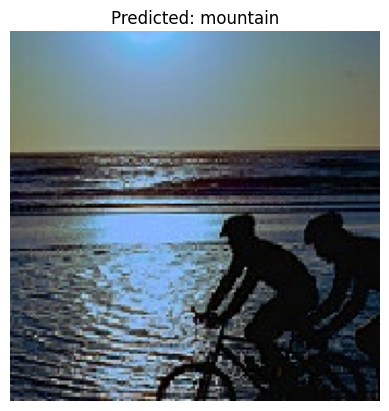

Predicted class: mountain


In [21]:
from pathlib import Path

image_path = "/content/drive/MyDrive/BSM VII/Deep Learning/Intel Image Classification Small/test/sea/20167.jpg"

print("Actual class:", Path(image_path).parent.name)
prediction = predict_scene(image_path, augmented_model)
print("Predicted class:", prediction)

Actual class: forest

--- Without augmentation ---
Predicted class: forest
Model probability: 100.00%


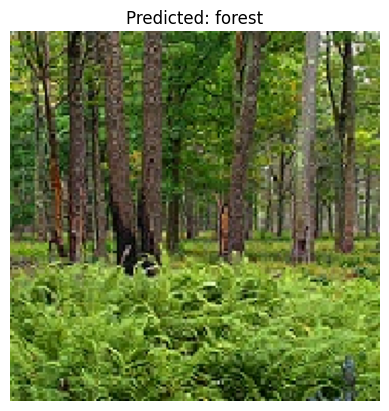


--- With augmentation and dropout ---
Predicted class: forest
Model probability: 99.91%


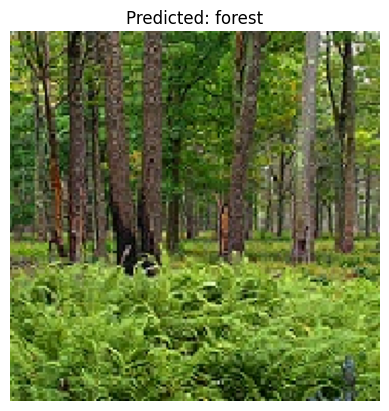


Comparison:
Actual class: forest
Without augmentation: forest
With augmentation: forest


In [26]:
from pathlib import Path

image_path = "/content/drive/MyDrive/BSM VII/Deep Learning/Intel Image Classification Small/train/forest/226.jpg"

print("Actual class:", Path(image_path).parent.name)

print("\n--- Without augmentation ---")
baseline_prediction = predict_scene(image_path, model)

print("\n--- With augmentation and dropout ---")
augmented_prediction = predict_scene(image_path, augmented_model)

print("\nComparison:")
print("Actual class:", Path(image_path).parent.name)
print("Without augmentation:", baseline_prediction)
print("With augmentation:", augmented_prediction)

### Model Comparison

The CNN without augmentation achieved **28% test accuracy**, while the CNN with augmentation and dropout achieved **34%**, an improvement of **6 percentage points**.

Augmentation and dropout likely reduced memorization and improved generalization. However, overall accuracy remained modest.